In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_csv('2) Stock Prices Data Set.csv')
df.head(5)

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  object 
 1   date    497472 non-null  object 
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 26.6+ MB


In [5]:
df.describe()

,open,high,low,close,volume
count,497461.000000,497464.000000,497464.000000,497472.000000,4.974720e+05
mean,86.352275,87.132562,85.552467,86.369082,4.253611e+06
std,101.471228,102.312062,100.570957,101.472407,8.232139e+06
min,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,41.690000,42.090000,41.280000,41.703750,1.080166e+06
50%,64.970000,65.560000,64.353700,64.980000,2.084896e+06
75%,98.410000,99.230000,97.580000,98.420000,4.271928e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


In [4]:
print(df.isna().sum())

symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64


In [6]:
df= df.dropna()

In [7]:
X = df[['open', 'high', 'low', 'volume']]
y = df['close']

#Split Data
X_train, X_test, y_train, y_test = train_test_split( X , y , test_size=0.2 , random_state=42)

In [8]:
#Model training
model = LinearRegression()
model.fit(X_train,y_train)


LinearRegression()

In [10]:
for name, coef in zip(X.columns, model.coef_):
    print(name, coef)

open -0.5380930447592581
high 0.7872510916021657
low 0.7509681880445243
volume -8.67090843570395e-11


In [11]:
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.999950468398244


In [12]:
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 0.5160296085853553


In [16]:
Numric_data = df.select_dtypes(include=['number'])
Numric_data.head(5)

,open,high,low,close,volume
0,25.0700,25.8200,25.0600,25.3600,8998943
1,79.3828,79.5756,78.8601,79.0185,58791957
2,110.3600,111.8800,109.2900,109.7400,542711
3,52.1200,52.3300,51.5200,51.9800,4569061
4,70.1100,70.2300,69.4800,69.8900,1148391


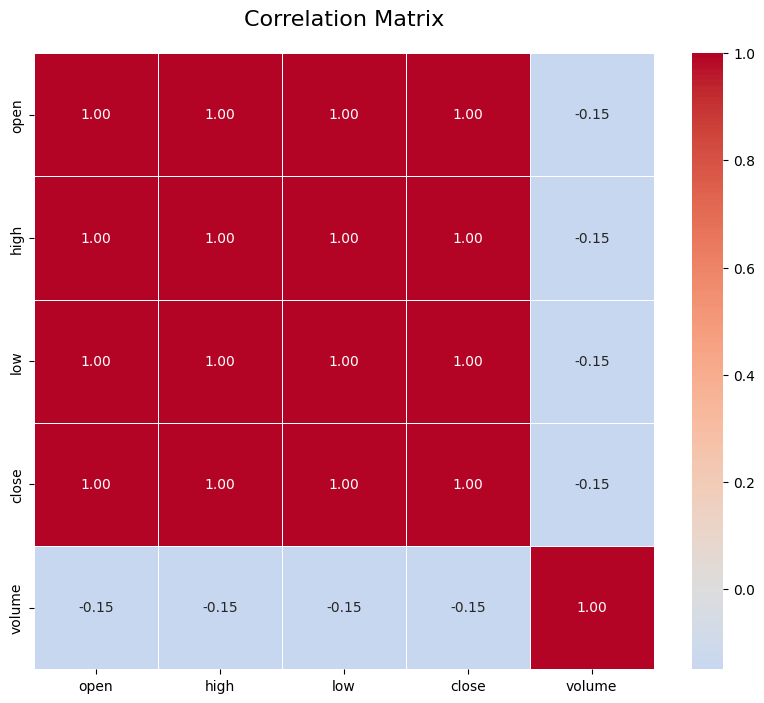

In [22]:
plt.figure(figsize=(10,8))
sns.heatmap(Numric_data.corr(), annot=True, cmap='coolwarm',center=0,
    linewidths=0.5,
    fmt=".2f" )
plt.title("Correlation Matrix", fontsize=16, pad=20)
plt.show()

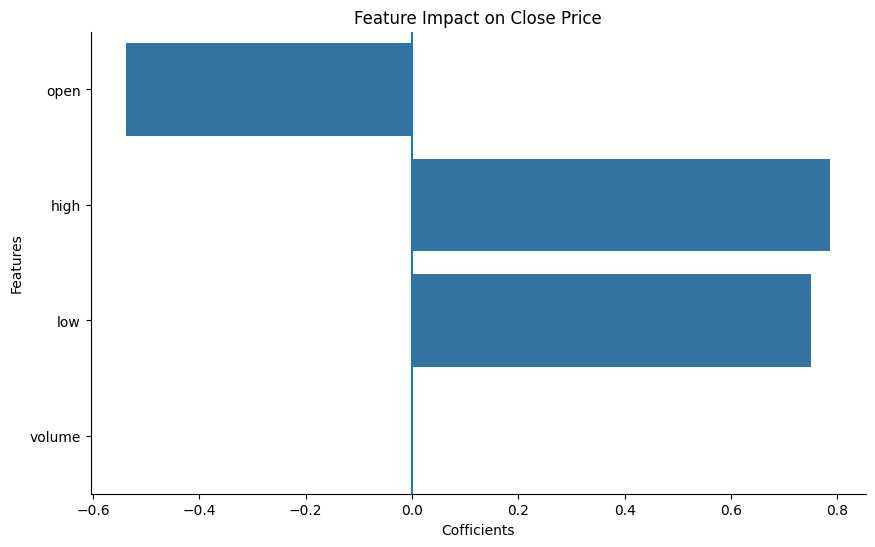

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

features = X.columns
Cofficients = model.coef_

plt.figure(figsize=(10, 6))
sns.barplot(x=Cofficients, y=features)

plt.title("Feature Impact on Close Price")
plt.axvline(0)
sns.despine()
plt.xlabel("Cofficients")
plt.ylabel("Features")
plt.show()

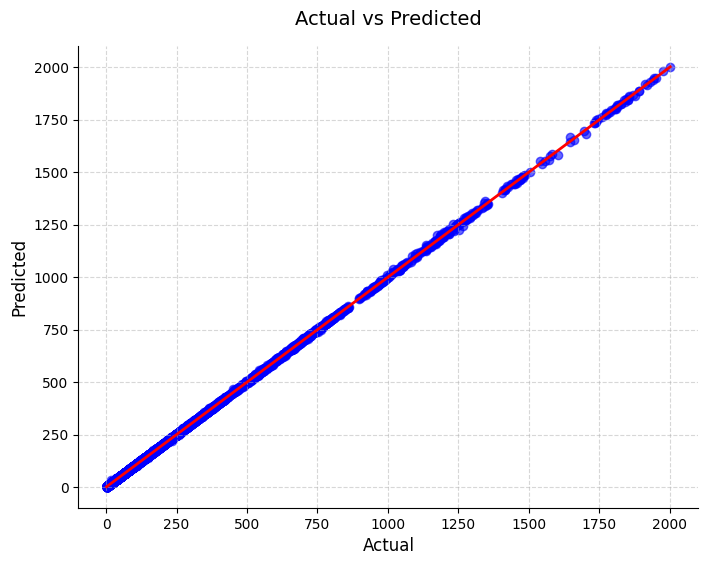

In [32]:
plt.figure(figsize=(8,6))
sns.regplot(
    x=y_test,
    y=y_pred,
    scatter_kws={'alpha':0.6, 'color':'blue'},
    line_kws={'color':'red', 'lw':2}
)
plt.xlabel("Actual", fontsize=12)
plt.ylabel("Predicted", fontsize=12)
plt.title("Actual vs Predicted", fontsize=14, pad=15)
plt.grid(True, linestyle='--', alpha=0.5)
sns.despine()
plt.show()
